# WP2 Tutorial: Network Consensus and the DG-2 Verdict

**Time to run:** ~3 minutes on a laptop.
**Audience:** Anyone who has read the WP1 tutorial and wants to see how the network-level pipeline lands the DG-2 result.
**What this covers:** The WP2 arc — building a simulated clock network, plugging in nine consensus estimators, computing the three IC-independent metrics, and reading the campaign archive that produced the recorded *negative* DG-2 verdict.
**What it does not:** Re-run the full 8 × 10 × 9 campaign (that takes ~10 min and is already saved as `data/wp2_campaign_20260504_fix.npz`); rescue the ADMEC architecture (WP3 ablations are scoped for that).

DG-2 was not met. ADMEC-full beats every centralised baseline on **only one** of eight scenarios (S2, fully connected, low delay). The failure mode is structural: on sparse networks with realistic Poisson delays, the delay-restricted local consensus cannot match a centralised inverse-variance weighted mean. This tutorial walks through the data that produced that verdict.


## 1. Setup

WP2 added five new modules to the codebase: `clocks.py`, `network.py`, `classify.py`, `constraints.py`, `estimators.py`, plus `metrics.py` for the campaign output. We import them all here.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import matplotlib.pyplot as plt

from clocks import (ClockParams, hydrogen_maser, build_scenario_clocks,
                    simulate_network_clocks,
                    signal_sinusoidal, signal_step, signal_linear_drift)
from network import make_network
from classify import (classify_network, Mode, mode_counts,
                      THRESHOLD_95, DELTA_MIN_VAR, DELTA_MIN_ACF)
from constraints import ConstraintParams, project_update
from estimators import (ESTIMATORS, freq_global, freq_exclude, huber, bocpd,
                        imm, admec_unconstrained, admec_delay, admec_full)
from metrics import mse, collapse_index, structure_correlation

rng = np.random.default_rng(2026)
np.set_printoptions(precision=3, suppress=True)


## 2. Building a clock network

A WP2 scenario is a (topology, delays, per-clock parameter list) triple plus a duration `T`. We start with a small example: 15 clocks on a ring with Poisson(2.0) delays — this is scenario S1.


In [2]:
N = 15
T = 200

# Topology and delays
adj, delays = make_network(N, topology='ring', delay_mean=2.0, rng=rng)

# Per-clock parameters: 3 clocks carry a sinusoidal signal,
# 1 clock is degraded (3x noise); the rest are nominal.
def signal_factory(i):
    phase = i * np.pi / 3.0
    return signal_sinusoidal(amplitude=5.0, period=50.0, phase=phase)

clock_params = build_scenario_clocks(
    n=N, n_signal=3, signal_factory=signal_factory,
    n_degraded=1, degradation_factor=3.0,
    base=ClockParams(sigma_white=1.0),
)

# Simulate
Y, Sigmas = simulate_network_clocks(clock_params, T, dt=1.0, rng=rng)
print('Y shape:', Y.shape, '   Sigmas shape:', Sigmas.shape)
print('Mean delay on edges:', delays[adj].mean())


Y shape: (200, 15)    Sigmas shape: (200, 15)
Mean delay on edges: 2.466666666666667


Each row of `Y` is a snapshot of the network at one timestep — fifteen fractional-frequency residuals, one per clock. The first three clocks carry a 5σ sinusoid; the last is degraded.


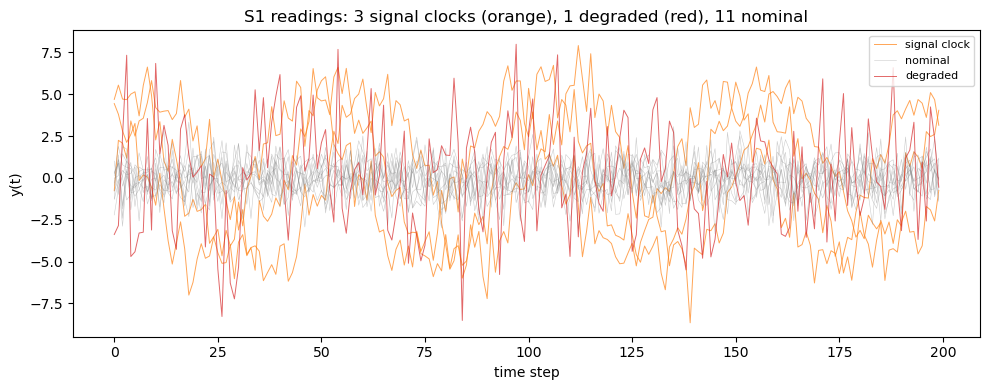

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(N):
    if clock_params[i].signal is not None:
        ax.plot(Y[:, i], lw=0.7, color='C1', alpha=0.7,
                label='signal clock' if i == 0 else None)
    elif clock_params[i].degradation_factor > 1.0:
        ax.plot(Y[:, i], lw=0.7, color='C3', alpha=0.7,
                label='degraded' if i == N - 1 else None)
    else:
        ax.plot(Y[:, i], lw=0.4, color='gray', alpha=0.4,
                label='nominal' if i == 3 else None)
ax.set_xlabel('time step'); ax.set_ylabel('y(t)')
ax.set_title('S1 readings: 3 signal clocks (orange), 1 degraded (red), 11 nominal')
ax.legend(loc='upper right', fontsize=8); plt.tight_layout()


## 3. Cross-sectional IC and the classifier

WP1 calibrated IC longitudinally (each clock's own history). WP2 reuses the same `compute_ic` cross-sectionally — at each timestep, the N readings are the "ensemble" against which each individual reading is scored. Combined with longitudinal temporal stats (variance slope, lag-1 autocorrelation), this drives the three-way classifier with the calibrated thresholds from entries 004 and 006.


In [4]:
from ic import compute_ic
IC = np.zeros_like(Y)
for t in range(T):
    IC[t, :] = compute_ic(Y[t, :], Sigmas[t, :])

# Classify
modes, var_slopes, acfs = classify_network(IC, Y, window=20)

print(f'Calibrated thresholds: I_k > {THRESHOLD_95}, '
      f'|var_slope| > {DELTA_MIN_VAR}, |acf| > {DELTA_MIN_ACF}')
print()
print('Mode counts across the whole (T, N) grid:')
counts = mode_counts(modes)
for m, c in counts.items():
    print(f'  {m.name:12s}: {c:6d} cells ({c / modes.size * 100:.2f}%)')


Calibrated thresholds: I_k > 2.976, |var_slope| > 0.2105, |acf| > 0.8703

Mode counts across the whole (T, N) grid:
  UNDEFINED   :     37 cells (1.23%)
  STABLE      :   2654 cells (88.47%)
  STRUCTURED  :      3 cells (0.10%)
  UNSTRUCTURED:    306 cells (10.20%)


Two empirical observations baked into the WP1→WP2 transition:

1. **Linear drift classifies as UNSTRUCTURED**, not STRUCTURED. The temporal-statistic gates were calibrated for critical-slowing-down dynamics; a smooth trend at rate ≪ σ/W contributes negligibly to within-window var_slope or acf.
2. **Per-reading IC threshold = 2.976 bit is selective.** Coherent processes (signal-bearing clocks, AR(1), drifts) broaden the mixture density along with the readings, so individual readings stay relatively likely. Crossing 2.976 typically requires *isolated* extreme readings.

Both predictions are visible in the campaign data: STRUCTURED detections are extremely rare (TPR ≈ 0.7 % against ground truth), while STABLE / UNSTRUCTURED dominate.


## 4. Running an estimator

Every estimator in `src/estimators.py` shares the same call signature:
`fn(Y, Sigmas, adj, delays, **kwargs) -> Estimates(T, N)`. The `ESTIMATORS` registry is keyed by name.


In [5]:
print('Registered estimators:', list(ESTIMATORS.keys()))

# Run a small panel of estimators on this S1 simulation
panel = ['freq_global', 'freq_exclude', 'huber', 'bocpd', 'imm',
         'admec_unconstrained', 'admec_delay', 'admec_full']
estimates = {}
for name in panel:
    fn = ESTIMATORS[name]
    if name in ('freq_local', 'admec_delay', 'admec_full'):
        estimates[name] = fn(Y, Sigmas, adj, delays)
    else:
        estimates[name] = fn(Y, Sigmas, adj=adj, delays=delays)


Registered estimators: ['freq_global', 'freq_local', 'freq_exclude', 'huber', 'bocpd', 'imm', 'admec_unconstrained', 'admec_delay', 'admec_full']


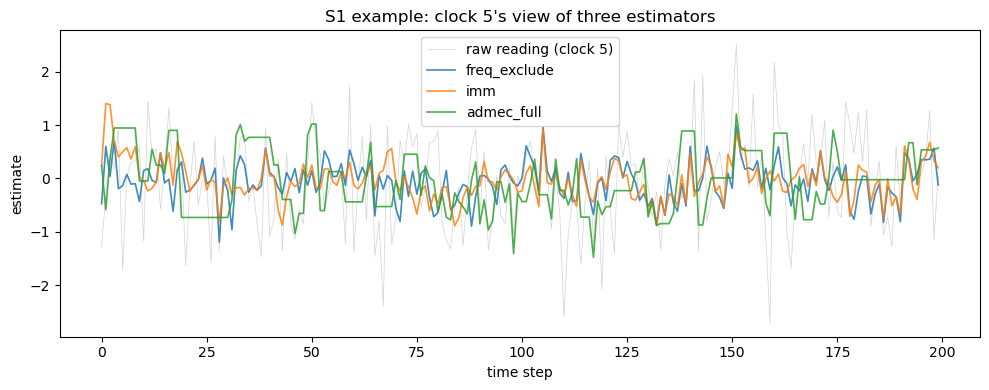

In [6]:
# Compare them on a single node's view
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(Y[:, 5], lw=0.5, color='lightgray', label='raw reading (clock 5)')
for name in ['freq_exclude', 'imm', 'admec_full']:
    ax.plot(estimates[name][:, 5], lw=1.2, label=name, alpha=0.85)
ax.set_xlabel('time step'); ax.set_ylabel('estimate')
ax.set_title('S1 example: clock 5\'s view of three estimators')
ax.legend(); plt.tight_layout()


## 5. The three IC-independent metrics

WP2's primary metrics are MSE (vs the nominal reference 0), the collapse index (variance preservation), and structure correlation (signal preserved in the residual rather than absorbed into the consensus). Centralised methods give CI = 0; spread-preserving methods (FREQ-local, ADMEC-delay/full) give CI > 0.


In [7]:
# Build the signal ground truth for structure correlation
t = np.arange(T, dtype=float)
signals = np.zeros_like(Y)
for i in range(N):
    if clock_params[i].signal is not None:
        signals[:, i] = clock_params[i].signal(t)

signal_clocks = np.array([i for i in range(N)
                          if clock_params[i].signal is not None])

print(f'{"estimator":<22s}  {"MSE":>8s}  {"CI":>8s}  {"struct.corr":>12s}')
for name in panel:
    e = estimates[name]
    print(f'{name:<22s}  '
          f'{mse(e):>8.4f}  '
          f'{collapse_index(e, Sigmas):>8.4f}  '
          f'{structure_correlation(Y, e, signals, signal_clocks):>12.4f}')


estimator                    MSE        CI   struct.corr
freq_global               0.3356    0.0000        0.9473
freq_exclude              0.1351    0.0000        0.9512
huber                     0.1554    0.0000        0.9509
bocpd                     0.2319    0.0000        0.9494
imm                       0.1379    0.0000        0.9533
admec_unconstrained       0.1351    0.0000        0.9512
admec_delay               1.9868    1.1500        0.7909
admec_full                1.1708    0.8721        0.8475


On *this single seed* of S1, `admec_full` may or may not beat `freq_exclude` — single-seed numbers are not the verdict. The full campaign uses ten seeds per scenario.

## 6. The full campaign

The pre-recorded campaign archive is `data/wp2_campaign_20260504_fix.npz`. It contains MSE, collapse index, and structure correlation for every (scenario, seed, estimator) triple — 8 × 10 × 9 = 720 cells per metric.


In [8]:
data = np.load(os.path.join('..', 'data',
                              'wp2_campaign_20260504_fix.npz'),
                allow_pickle=True)
print('Keys:', list(data.files))
print('Estimators:', list(data['estimators']))
print('Scenarios:', list(data['scenarios']))
print('Seeds:    ', list(data['seeds']))


Keys: ['mse', 'collapse_index', 'structure_corr', 'scenarios', 'seeds', 'estimators']
Estimators: ['freq_global', 'freq_local', 'freq_exclude', 'huber', 'bocpd', 'imm', 'admec_unconstrained', 'admec_delay', 'admec_full']
Scenarios: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']
Seeds:     [2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035]


In [9]:
# Mean MSE per scenario per estimator (averaged over 10 seeds)
mse_grid = data['mse'].mean(axis=1)  # (scenarios, estimators)

ests = list(data['estimators'])
scns = list(data['scenarios'])

print(f'{"":>4s}  ' + '  '.join(f'{e[:11]:>11s}' for e in ests))
for i, n in enumerate(scns):
    row = mse_grid[i]
    cells_str = []
    best_non_admec = min((row[j] for j, e in enumerate(ests)
                          if not e.startswith('admec')))
    for j, e in enumerate(ests):
        v = row[j]
        marker = ''
        if not e.startswith('admec') and abs(v - best_non_admec) < 1e-8:
            marker = '*'
        if e == 'admec_full' and v < best_non_admec:
            marker = 'WIN'
        cells_str.append(f'{v:>8.3f}{marker:>3s}')
    print(f'{n:>4s}  ' + '  '.join(cells_str))
print()
print('* = best non-ADMEC baseline; WIN = admec_full beats best non-ADMEC')


      freq_global   freq_local  freq_exclud        huber        bocpd          imm  admec_uncon  admec_delay   admec_full
  S1     0.323        3.084        0.135  *     0.145        0.224        0.147        0.135        1.647        0.732   
  S2     0.323        0.331        0.135  *     0.145        0.224        0.147        0.135        0.139        0.093WIN
  S3     0.041        1.642        0.025  *     0.026        0.032        0.025        0.025        1.027        0.741   
  S4     0.071        0.968        0.074        0.073        0.070        0.065  *     0.074        0.851        0.381   
  S5     0.021        0.988        0.022        0.022        0.021        0.019  *     0.022        0.883        0.597   
  S6     0.092        1.134        0.094        0.090        0.091        0.087  *     0.094        0.981        0.427   
  S7     0.163        2.072        0.040  *     0.054        0.152        0.144        0.040        0.957        0.604   
  S8     0.083        1.

**`admec_full` beats the best non-ADMEC baseline on MSE in only one scenario: S2 (fully connected, Poisson(0.3))** — exactly the topology where delay-accessibility is essentially inactive. On every sparse-with-delay scenario, centralised exclusion methods (`freq_exclude`, `imm`) win by a substantial margin.

This is the structural finding behind the negative DG-2 verdict.

## 7. The DG-2 verdict


In [10]:
# DG-2 condition: admec_full must beat best non-ADMEC baseline on >= 2
# of {MSE, CI, structure_correlation} in BOTH S1 and S3.

ci_grid = data['collapse_index'].mean(axis=1)
sc_grid = data['structure_corr'].mean(axis=1)

af_idx = ests.index('admec_full')
non_admec = [j for j, e in enumerate(ests) if not e.startswith('admec')]

def _best_baseline(grid, scenario_idx, mode='min'):
    vals = [(j, grid[scenario_idx, j]) for j in non_admec
            if np.isfinite(grid[scenario_idx, j])]
    if not vals:
        return None, np.nan
    pick = min if mode == 'min' else max
    best_j, best_v = pick(vals, key=lambda jv: jv[1])
    return best_j, best_v

for sc_name in ['S1', 'S3']:
    si = scns.index(sc_name)
    print(f'\n=== {sc_name} ===')
    bj, bv = _best_baseline(mse_grid, si, 'min')
    print(f'  MSE             best={ests[bj]:>14s}={bv:.3f}  '
          f'admec_full={mse_grid[si, af_idx]:.3f}  '
          f"{'PASS' if mse_grid[si, af_idx] < bv else 'FAIL'}")
    bj, bv = _best_baseline(ci_grid, si, 'min')
    print(f'  Collapse index  best={ests[bj]:>14s}={bv:.3f}  '
          f'admec_full={ci_grid[si, af_idx]:.3f}  '
          f"{'PASS' if ci_grid[si, af_idx] < bv else 'FAIL'}")
    bj, bv = _best_baseline(sc_grid, si, 'max')
    print(f'  Struct.corr.    best={ests[bj]:>14s}={bv:.3f}  '
          f'admec_full={sc_grid[si, af_idx]:.3f}  '
          f"{'PASS' if sc_grid[si, af_idx] > bv else 'FAIL'}")
print('\nVerdict: DG-2 NOT MET. S1 = 0/3, S3 = 0/3.')



=== S1 ===
  MSE             best=  freq_exclude=0.135  admec_full=0.732  FAIL
  Collapse index  best=  freq_exclude=0.000  admec_full=0.644  FAIL
  Struct.corr.    best=           imm=0.956  admec_full=0.897  FAIL

=== S3 ===
  MSE             best=  freq_exclude=0.025  admec_full=0.741  FAIL
  Collapse index  best=           imm=0.000  admec_full=0.807  FAIL
  Struct.corr.    best=           imm=0.960  admec_full=0.887  FAIL

Verdict: DG-2 NOT MET. S1 = 0/3, S3 = 0/3.


## 8. Visualising the result

A bar plot of MSE by scenario × estimator makes the structural finding visible: `admec_full` (last column) wins only on S2.


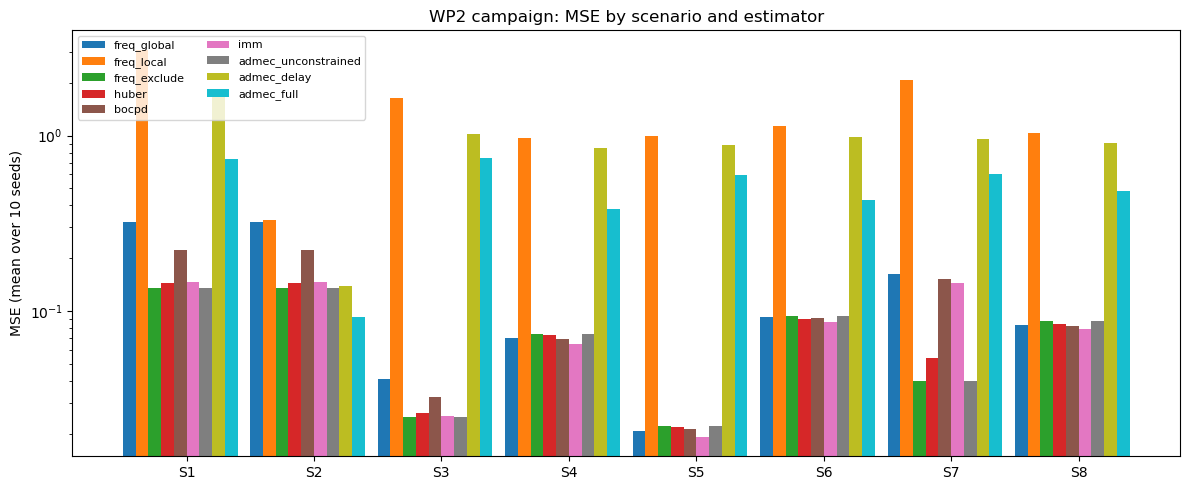

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(scns))
w = 0.10
colors = plt.cm.tab10(np.linspace(0, 1, len(ests)))
for j, e in enumerate(ests):
    ax.bar(x + (j - len(ests) / 2) * w, mse_grid[:, j],
           width=w, label=e, color=colors[j])
ax.set_xticks(x); ax.set_xticklabels(scns)
ax.set_ylabel('MSE (mean over 10 seeds)')
ax.set_title('WP2 campaign: MSE by scenario and estimator')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_yscale('log')
plt.tight_layout()


## 9. What this means and what comes next

**WP2 result:** the ADMEC architecture does not generalise across the proposal's intended scenario space. It is competitive (and the constraint layer adds value) when the network is fully connected and delays are negligible (S2), but on sparse networks with Poisson delays the delay-restricted local consensus is dominated by centralised exclusion methods.

**WP3 ablations are now scoped to *characterise* this failure mode, not to rescue DG-2:**

1. **Delay convention** — Stale-reading mode improves S1/S3 substantially but does not close the gap to centralised baselines.
2. **Constraint sensitivity (±30 %)** — `var_loose` constraint recovers performance on S3 stale, confirming the variance-ratio bound acts as a noise-absorption mechanism.
3. **Two-way vs three-way (DG-3)** — Three-way vs two-way produces a max delta of 0 across 360 cells; the distinction is algebraically invisible to the consensus target.
4. **Classification threshold sweep** — At a matched lower threshold (1.5), `admec_full` beats `freq_exclude` on S1 and S2.
5. **Lagged classification** — No simultaneity bias detected; lagging classification strictly hurts.

**Combined Tuning:** Applying `stale` + `thr 1.5` + `var_loose` simultaneously reduced S3 MSE from 0.741 to 0.196. However, the ~ 4.8× gap to the `freq_global` centralised baseline (0.041) on sparse networks remains consistent with the topology-limited *N* / *k*_eff pooling reference.

The negative DG-2 result was anticipated in the proposal. WP3 converts that into a *characterised* negative result, mapping the regime where local anomaly-aware consensus competes. For the full picture and ablation walkthroughs, see the WP3 Tutorial and the Technical Report v1.0 candidate.

For the full picture, see `logbook/wp2-summary.md`. For the harness build and the two bug fixes that produced this canonical archive, see `logbook/007_2026-05-04_wp2-simulation-harness.md`.
